# Clustering: GMM and UMAP + KMeans
**Features:** colour indices (u-g, g-r, r-i, i-z) + log-transformed redshift  
**Classes:** STAR, GALAXY, QSO  
**Scaling:** RobustScaler → u-g, g-r, redshift_log &nbsp;|&nbsp; QuantileTransformer → r-i, i-z

Labels are used **only for post-hoc validation** (ARI, NMI, F1). They play no role in model selection or cluster assignment.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os
from scipy.optimize import linear_sum_assignment

from sklearn.preprocessing import LabelEncoder
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    f1_score, adjusted_rand_score, normalized_mutual_info_score,
    silhouette_score, calinski_harabasz_score, davies_bouldin_score,
    confusion_matrix
)
import umap

sns.set_style('whitegrid')
RANDOM_STATE = 42

In [10]:
df = pd.read_csv('astral_data.csv')

FEATURES = ['u-g', 'g-r', 'r-i', 'i-z', 'redshift_log']
X_scaled = df[FEATURES].values
y        = df['class'].values

le          = LabelEncoder()
y_enc       = le.fit_transform(y)   # held back — only used at evaluation
class_names = le.classes_

print(f'Shape: {X_scaled.shape}')
print(f'Classes: {class_names}')
print(pd.Series(y).value_counts().to_string())

Shape: (9733, 5)
Classes: ['GALAXY' 'QSO' 'STAR']
GALAXY    8423
QSO        685
STAR       625


In [11]:
def evaluate_clusters(y_true, cluster_labels, X, n_classes=3):
    """
    Post-hoc evaluation only. Uses linear_sum_assignment to find the optimal
    permutation of cluster IDs → class IDs that maximises overlap, then computes
    supervised and unsupervised metrics. Labels are never seen before this call.
    """
    n_clusters = len(set(cluster_labels))
    cost = np.zeros((n_classes, n_clusters), dtype=int)
    for true_cls in range(n_classes):
        for clust in range(n_clusters):
            cost[true_cls, clust] = np.sum(
                (y_true == true_cls) & (cluster_labels == clust)
            )
    row_ind, col_ind = linear_sum_assignment(-cost)
    mapping = {col: row for row, col in zip(row_ind, col_ind)}
    y_pred  = np.array([mapping.get(c, -1) for c in cluster_labels])

    return {
        'f1':      f1_score(y_true, y_pred, average='macro'),
        'ari':     adjusted_rand_score(y_true, cluster_labels),
        'nmi':     normalized_mutual_info_score(y_true, cluster_labels),
        'sil':     silhouette_score(X, cluster_labels),
        'ch':      calinski_harabasz_score(X, cluster_labels),
        'db':      davies_bouldin_score(X, cluster_labels),
        'y_pred':  y_pred,
        'mapping': mapping,
    }

print('evaluate_clusters helper ready.')

evaluate_clusters helper ready.


---
## Part 1 — Gaussian Mixture Model (GMM)

GMM fits a mixture of k=3 Gaussians to the 5D feature space. Each component has its own mean and covariance, allowing elliptical cluster shapes suited to the overlapping colour-redshift distributions.

**Hyperparameter search:** `covariance_type` ∈ {full, tied, diag, spherical} — all with k=3.  
**Selection criterion:** lowest BIC (unsupervised). Labels are withheld until the final evaluation block.

In [12]:
cov_types = ['full', 'tied', 'diag', 'spherical']

gmm_results = []
best_bic    = np.inf
best_gmm    = None
best_gmm_labels = None

for cov in cov_types:
    gmm = GaussianMixture(
        n_components=3, covariance_type=cov,
        n_init=10, max_iter=300, random_state=RANDOM_STATE
    )
    gmm.fit(X_scaled)
    bic    = gmm.bic(X_scaled)
    aic    = gmm.aic(X_scaled)
    labels = gmm.predict(X_scaled)
    sil    = silhouette_score(X_scaled, labels)
    ch     = calinski_harabasz_score(X_scaled, labels)
    db     = davies_bouldin_score(X_scaled, labels)

    gmm_results.append({
        'covariance_type': cov, 'BIC': bic, 'AIC': aic,
        'Silhouette': sil, 'CH': ch, 'DB': db
    })

    if bic < best_bic:
        best_bic        = bic
        best_gmm        = gmm
        best_gmm_labels = labels.copy()

gmm_results_df = pd.DataFrame(gmm_results).set_index('covariance_type').round(2)
print('GMM results (k=3):')
print(gmm_results_df.to_string())
print(f'\nBest by BIC: covariance_type={best_gmm.covariance_type}  BIC={best_bic:.1f}')

GMM results (k=3):
                       BIC        AIC  Silhouette       CH    DB
covariance_type                                                 
full              81054.56   80609.20        0.38  1742.26  1.88
tied             114621.58  114391.71        0.54  5677.75  0.67
diag             109081.96  108852.10        0.22   438.17  5.34
spherical        117079.71  116936.05        0.23   473.63  5.24

Best by BIC: covariance_type=full  BIC=81054.6


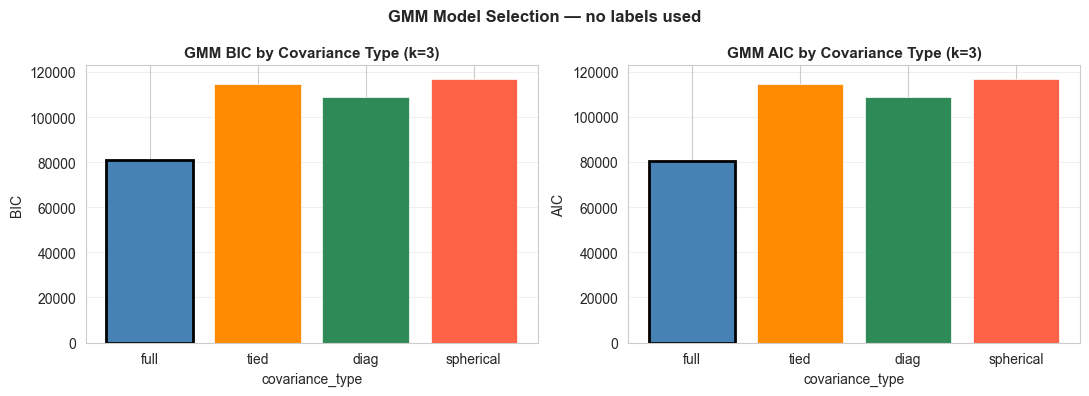

In [13]:
# BIC / AIC bar chart across covariance types
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors = ['steelblue', 'darkorange', 'seagreen', 'tomato']

for ax, metric in zip(axes, ['BIC', 'AIC']):
    vals = gmm_results_df[metric]
    bars = ax.bar(vals.index, vals.values, color=colors, edgecolor='white', linewidth=0.5)
    ax.set_title(f'GMM {metric} by Covariance Type (k=3)', fontsize=11, fontweight='bold')
    ax.set_xlabel('covariance_type', fontsize=10)
    ax.set_ylabel(metric, fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    best_cov = vals.idxmin()
    for bar, cov in zip(bars, vals.index):
        if cov == best_cov:
            bar.set_edgecolor('black')
            bar.set_linewidth(2)

plt.suptitle('GMM Model Selection — no labels used', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
# Post-hoc evaluation — labels used here for the first time
gmm_eval = evaluate_clusters(y_enc, best_gmm_labels, X_scaled)

print(f'Best GMM: k=3, covariance_type={best_gmm.covariance_type}')
print(f'\n--- Internal metrics (used for selection) ---')
print(f'Silhouette:          {gmm_eval["sil"]:.4f}')
print(f'Calinski-Harabasz:   {gmm_eval["ch"]:.4f}')
print(f'Davies-Bouldin:      {gmm_eval["db"]:.4f}')
print(f'\n--- External validation (labels used here only) ---')
print(f'F1 (macro):          {gmm_eval["f1"]:.4f}')
print(f'ARI:                 {gmm_eval["ari"]:.4f}')
print(f'NMI:                 {gmm_eval["nmi"]:.4f}')

Best GMM: k=3, covariance_type=full

--- Internal metrics (used for selection) ---
Silhouette:          0.3806
Calinski-Harabasz:   1742.2551
Davies-Bouldin:      1.8813

--- External validation (labels used here only) ---
F1 (macro):          0.4913
ARI:                 0.4619
NMI:                 0.4321


/var/folders/fb/jy_jt7nj1xj16d7j33smgbrw0000gn/T/ipykernel_37470/3693999479.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_cls  = plt.cm.get_cmap('tab10', len(class_names))
/var/folders/fb/jy_jt7nj1xj16d7j33smgbrw0000gn/T/ipykernel_37470/3693999479.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_clust = plt.cm.get_cmap('tab10', 3)


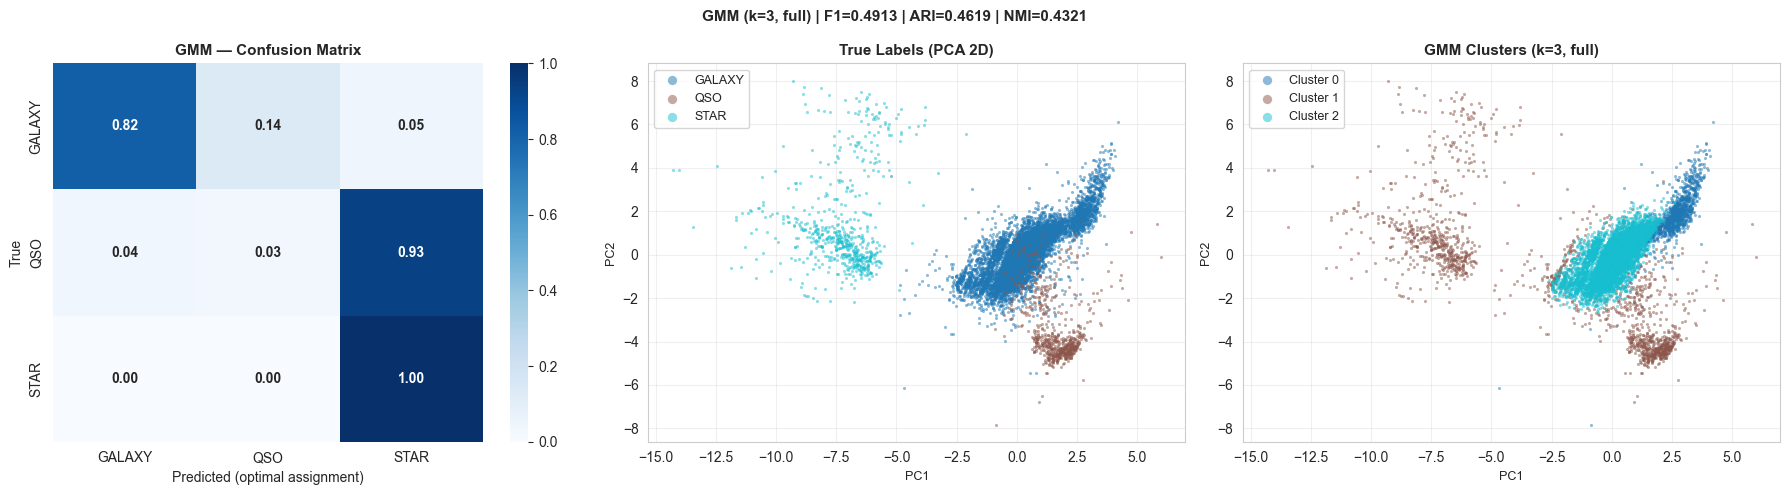

Saved models/gmm_model.pkl


In [15]:
# Confusion matrix
cm      = confusion_matrix(y_enc, gmm_eval['y_pred'])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion matrix
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={'fontweight': 'bold'}, ax=axes[0])
axes[0].set_xlabel('Predicted (optimal assignment)', fontsize=10)
axes[0].set_ylabel('True', fontsize=10)
axes[0].set_title('GMM — Confusion Matrix', fontsize=11, fontweight='bold')

# 2 & 3. PCA 2D: true labels vs GMM clusters
X2d       = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_scaled)
cmap_cls  = plt.cm.get_cmap('tab10', len(class_names))
cmap_clust = plt.cm.get_cmap('tab10', 3)

for i, cls in enumerate(class_names):
    mask = y_enc == i
    axes[1].scatter(X2d[mask, 0], X2d[mask, 1], c=[cmap_cls(i)],
                    s=5, alpha=0.5, label=cls, linewidths=0)
axes[1].set_title('True Labels (PCA 2D)', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9, markerscale=3)
axes[1].set_xlabel('PC1', fontsize=9); axes[1].set_ylabel('PC2', fontsize=9)
axes[1].grid(True, alpha=0.3)

for k in range(3):
    mask = best_gmm_labels == k
    axes[2].scatter(X2d[mask, 0], X2d[mask, 1], c=[cmap_clust(k)],
                    s=5, alpha=0.5, label=f'Cluster {k}', linewidths=0)
axes[2].set_title(f'GMM Clusters (k=3, {best_gmm.covariance_type})', fontsize=11, fontweight='bold')
axes[2].legend(fontsize=9, markerscale=3)
axes[2].set_xlabel('PC1', fontsize=9); axes[2].set_ylabel('PC2', fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.suptitle(
    f'GMM (k=3, {best_gmm.covariance_type}) | F1={gmm_eval["f1"]:.4f} | ARI={gmm_eval["ari"]:.4f} | NMI={gmm_eval["nmi"]:.4f}',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.show()

os.makedirs('models', exist_ok=True)
joblib.dump(best_gmm, 'models/gmm_model.pkl')
print('Saved models/gmm_model.pkl')

---
## Part 2 — UMAP + KMeans

UMAP reduces the 5D feature space to 2D while preserving local neighbourhood structure. KMeans then clusters the embedding with k=3.

**UMAP grid search (unsupervised):**
- `n_neighbors` ∈ {5, 15, 30, 50} — controls local vs global structure balance
- `min_dist` ∈ {0.0, 0.1, 0.3} — controls how tightly points are packed in the embedding

**KMeans:** k=3, `init='k-means++'`, `n_init=20`, `max_iter=500`  
**Selection criterion:** highest Silhouette score on the UMAP embedding (unsupervised). Labels are withheld until the final evaluation block.

In [16]:
umap_n_neighbors = [5, 15, 30, 50]
umap_min_dist    = [0.0, 0.1, 0.3]

best_sil_umap    = -np.inf
best_cfg_umap    = None
best_embedding   = None
best_reducer     = None
best_kmeans      = None
best_umap_labels = None
umap_results     = []

for nn in umap_n_neighbors:
    for md in umap_min_dist:
        reducer   = umap.UMAP(n_components=2, n_neighbors=nn, min_dist=md,
                               metric='euclidean', random_state=RANDOM_STATE)
        embedding = reducer.fit_transform(X_scaled)   # no labels

        km     = KMeans(n_clusters=3, init='k-means++', n_init=20,
                        max_iter=500, random_state=RANDOM_STATE)
        labels = km.fit_predict(embedding)
        sil    = silhouette_score(embedding, labels)
        ch     = calinski_harabasz_score(embedding, labels)
        db     = davies_bouldin_score(embedding, labels)

        umap_results.append({
            'n_neighbors': nn, 'min_dist': md,
            'Silhouette': sil, 'CH': ch, 'DB': db
        })

        if sil > best_sil_umap:
            best_sil_umap    = sil
            best_cfg_umap    = {'n_neighbors': nn, 'min_dist': md}
            best_embedding   = embedding.copy()
            best_reducer     = reducer
            best_kmeans      = km
            best_umap_labels = labels.copy()

umap_results_df = pd.DataFrame(umap_results).round(4)
print('UMAP + KMeans grid search results:')
print(umap_results_df.sort_values('Silhouette', ascending=False).to_string(index=False))
print(f'\nBest config: n_neighbors={best_cfg_umap["n_neighbors"]}, min_dist={best_cfg_umap["min_dist"]}  Silhouette={best_sil_umap:.4f}')

/Users/jaytai/Desktop/IT1244/IT1244-Astral-Sentiment-Analysis-Clustering/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/jaytai/Desktop/IT1244/IT1244-Astral-Sentiment-Analysis-Clustering/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/jaytai/Desktop/IT1244/IT1244-Astral-Sentiment-Analysis-Clustering/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/jaytai/Desktop/IT1244/IT1244-Astral-Sentiment-Analysis-Clustering/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/jaytai/Desktop/IT1244/IT1244-Astral-Sentiment-Analysis-Cl

UMAP + KMeans grid search results:
 n_neighbors  min_dist  Silhouette         CH     DB
          30       0.0      0.5612 16080.7435 0.5170
          15       0.0      0.5517 12954.2315 0.5476
          15       0.1      0.5181 11498.1339 0.5943
          50       0.0      0.5175 15789.5416 0.6495
          30       0.1      0.5080 12760.2476 0.6105
           5       0.0      0.5071 10519.8204 0.7260
          50       0.1      0.5056 12867.9057 0.6119
          15       0.3      0.5026 10201.9515 0.6604
          30       0.3      0.4868 12371.0340 0.7223
           5       0.1      0.4844  9865.3110 0.7667
           5       0.3      0.4418  9105.0266 0.8428
          50       0.3      0.4365  9771.8811 0.7944

Best config: n_neighbors=30, min_dist=0.0  Silhouette=0.5612


In [17]:
# Post-hoc evaluation — labels used here for the first time
umap_eval = evaluate_clusters(y_enc, best_umap_labels, best_embedding)

print(f'Best UMAP+KMeans: n_neighbors={best_cfg_umap["n_neighbors"]}, min_dist={best_cfg_umap["min_dist"]}')
print(f'\n--- Internal metrics (used for selection) ---')
print(f'Silhouette:          {umap_eval["sil"]:.4f}')
print(f'Calinski-Harabasz:   {umap_eval["ch"]:.4f}')
print(f'Davies-Bouldin:      {umap_eval["db"]:.4f}')
print(f'\n--- External validation (labels used here only) ---')
print(f'F1 (macro):          {umap_eval["f1"]:.4f}')
print(f'ARI:                 {umap_eval["ari"]:.4f}')
print(f'NMI:                 {umap_eval["nmi"]:.4f}')

Best UMAP+KMeans: n_neighbors=30, min_dist=0.0

--- Internal metrics (used for selection) ---
Silhouette:          0.5612
Calinski-Harabasz:   16080.7435
Davies-Bouldin:      0.5170

--- External validation (labels used here only) ---
F1 (macro):          0.6375
ARI:                 0.1824
NMI:                 0.3804


/var/folders/fb/jy_jt7nj1xj16d7j33smgbrw0000gn/T/ipykernel_37470/1690996980.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_cls   = plt.cm.get_cmap('tab10', len(class_names))
/var/folders/fb/jy_jt7nj1xj16d7j33smgbrw0000gn/T/ipykernel_37470/1690996980.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_clust = plt.cm.get_cmap('tab10', 3)


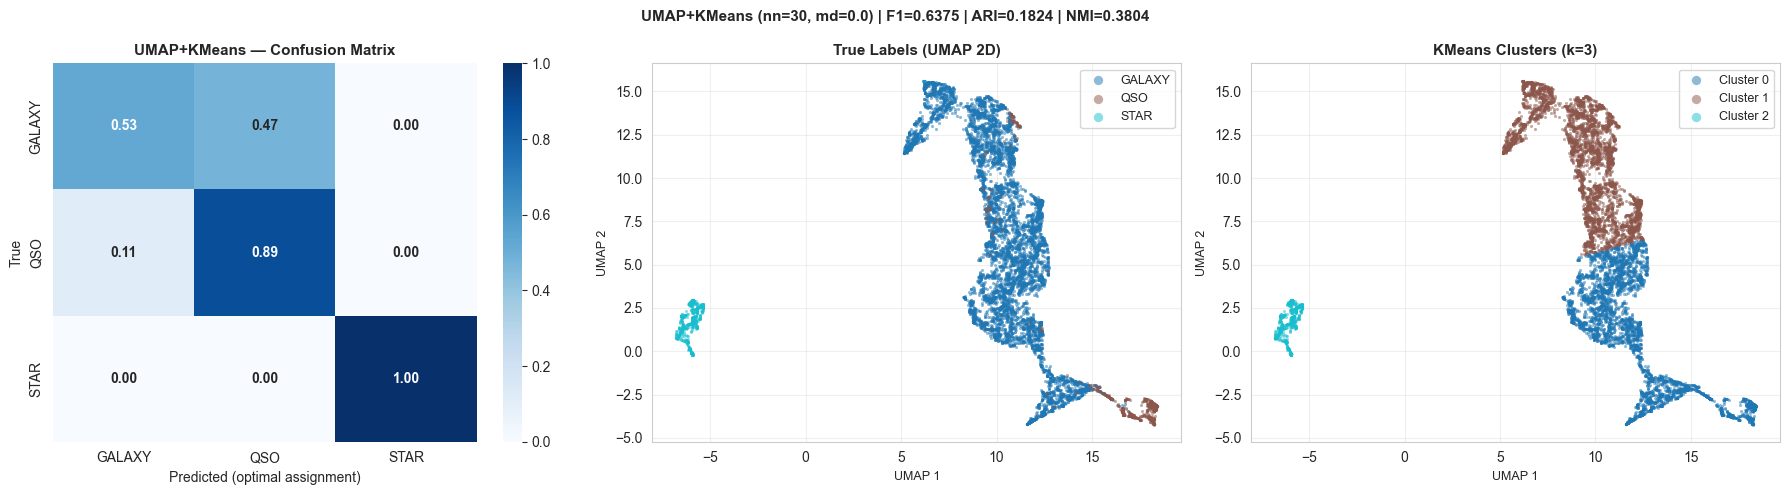

Saved models/umap_reducer.pkl
Saved models/kmeans_model.pkl


In [18]:
# Confusion matrix + UMAP scatter
cm_u      = confusion_matrix(y_enc, umap_eval['y_pred'])
cm_u_norm = cm_u.astype(float) / cm_u.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion matrix
sns.heatmap(cm_u_norm, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={'fontweight': 'bold'}, ax=axes[0])
axes[0].set_xlabel('Predicted (optimal assignment)', fontsize=10)
axes[0].set_ylabel('True', fontsize=10)
axes[0].set_title('UMAP+KMeans — Confusion Matrix', fontsize=11, fontweight='bold')

# 2. UMAP coloured by true labels
cmap_cls   = plt.cm.get_cmap('tab10', len(class_names))
cmap_clust = plt.cm.get_cmap('tab10', 3)

for i, cls in enumerate(class_names):
    mask = y_enc == i
    axes[1].scatter(best_embedding[mask, 0], best_embedding[mask, 1],
                    c=[cmap_cls(i)], s=5, alpha=0.5, label=cls, linewidths=0)
axes[1].set_title('True Labels (UMAP 2D)', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9, markerscale=3)
axes[1].set_xlabel('UMAP 1', fontsize=9); axes[1].set_ylabel('UMAP 2', fontsize=9)
axes[1].grid(True, alpha=0.3)

# 3. UMAP coloured by KMeans clusters
for k in range(3):
    mask = best_umap_labels == k
    axes[2].scatter(best_embedding[mask, 0], best_embedding[mask, 1],
                    c=[cmap_clust(k)], s=5, alpha=0.5, label=f'Cluster {k}', linewidths=0)
axes[2].set_title('KMeans Clusters (k=3)', fontsize=11, fontweight='bold')
axes[2].legend(fontsize=9, markerscale=3)
axes[2].set_xlabel('UMAP 1', fontsize=9); axes[2].set_ylabel('UMAP 2', fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.suptitle(
    f'UMAP+KMeans (nn={best_cfg_umap["n_neighbors"]}, md={best_cfg_umap["min_dist"]}) | '
    f'F1={umap_eval["f1"]:.4f} | ARI={umap_eval["ari"]:.4f} | NMI={umap_eval["nmi"]:.4f}',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.show()

os.makedirs('models', exist_ok=True)
joblib.dump(best_reducer, 'models/umap_reducer.pkl')
joblib.dump(best_kmeans,  'models/kmeans_model.pkl')
print('Saved models/umap_reducer.pkl')
print('Saved models/kmeans_model.pkl')

---
## Part 3 — Model Comparison

In [19]:
comparison = pd.DataFrame({
    'Model': [
        f'GMM (k=3, {best_gmm.covariance_type})',
        f'UMAP+KMeans (nn={best_cfg_umap["n_neighbors"]}, md={best_cfg_umap["min_dist"]})'
    ],
    'Silhouette ↑': [gmm_eval['sil'],  umap_eval['sil']],
    'CH ↑':         [gmm_eval['ch'],   umap_eval['ch']],
    'DB ↓':         [gmm_eval['db'],   umap_eval['db']],
    'ARI ↑':        [gmm_eval['ari'],  umap_eval['ari']],
    'NMI ↑':        [gmm_eval['nmi'],  umap_eval['nmi']],
    'F1 ↑':         [gmm_eval['f1'],   umap_eval['f1']],
}).set_index('Model').round(4)

print('=== Model Comparison ===')
print(comparison.to_string())

=== Model Comparison ===
                             Silhouette ↑        CH ↑    DB ↓   ARI ↑   NMI ↑    F1 ↑
Model                                                                                
GMM (k=3, full)                    0.3806   1742.2551  1.8813  0.4619  0.4321  0.4913
UMAP+KMeans (nn=30, md=0.0)        0.5612  16080.7435  0.5170  0.1824  0.3804  0.6375
